<a href="https://colab.research.google.com/github/anshika-a01/employee-turnover-prediction-model/blob/main/Employee_turnover_Model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Employee Turnover Prediction using Machine Learning

## 1. Import Required Libraries


In [ ]:
import pandas as pd
import numpy as np

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split

## 2. Load the Dataset

In [ ]:
df = pd.read_csv('HR_EMPLOYEE_ATTRITION.csv')

In [ ]:
df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EnvironmentSatisfaction,Gender,...,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,1,2,1102,2,1,2,1,2,0,...,3,1,0,8,0,1,6,4,0,5
1,49,0,1,279,1,8,1,1,3,1,...,4,4,1,10,3,3,10,7,1,7
2,37,1,2,1373,1,2,2,4,4,1,...,3,2,0,7,3,3,0,0,0,0
3,33,0,1,1392,1,3,4,1,4,0,...,3,3,0,8,3,3,8,7,3,0
4,27,0,2,591,1,2,1,3,1,1,...,3,4,1,6,3,3,2,2,2,2


## 4. Dataset Overview
### Check Dataset Shape

In [ ]:
df.shape

(1470, 35)

### Dataset Information

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

### Check Missing Values

In [ ]:
df.isnull().sum()

,0
Age,0
Attrition,0
BusinessTravel,0
DailyRate,0
Department,0
DistanceFromHome,0
Education,0
EducationField,0
EmployeeCount,0
EmployeeNumber,0


## 5. Data Cleaning
### Remove Unnecessary Columns

In [ ]:
#columns provide no predictive value
df.drop(columns=[
    'EmployeeCount',
    'EmployeeNumber',
    'Over18',
    'StandardHours'
], inplace=True)

In [ ]:
df.columns

Index(['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department',
       'DistanceFromHome', 'Education', 'EducationField',
       'EnvironmentSatisfaction', 'Gender', 'HourlyRate', 'JobInvolvement',
       'JobLevel', 'JobRole', 'JobSatisfaction', 'MaritalStatus',
       'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'OverTime',
       'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction',
       'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear',
       'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole',
       'YearsSinceLastPromotion', 'YearsWithCurrManager'],
      dtype='object')

## 6. Target Variable Analysis
### Check Unique Values

In [ ]:
print(df['Attrition'].unique())

['Yes' 'No']


### Converting Target Labels (Yes/No → 1/0)

In [ ]:
df['Attrition'] = df['Attrition'].map({
    'Yes': 1,
    'No': 0
})

In [ ]:
print(df['Attrition'].value_counts())

Attrition
0    1233
1     237
Name: count, dtype: int64


### Check Class Distribution

Attrition
0    1233
1     237
Name: count, dtype: int64


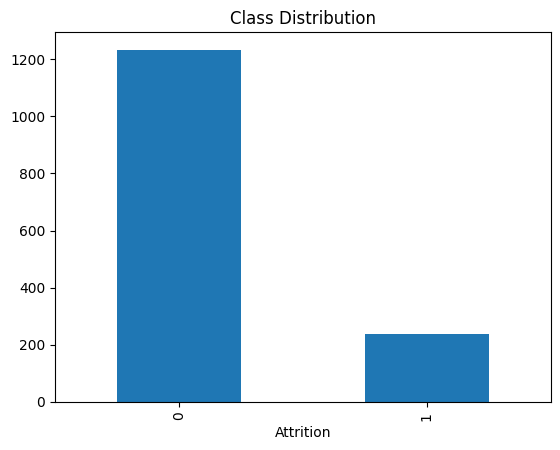

In [ ]:
print(df['Attrition'].value_counts())

import matplotlib.pyplot as plt

df['Attrition'].value_counts().plot(kind='bar')
plt.title("Class Distribution")
plt.show()

## 7. Encode Categorical Features
### Apply Label Encoding

In [ ]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

categorical_cols = df.select_dtypes(include='object').columns

print(categorical_cols)

Index(['BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole',
       'MaritalStatus', 'OverTime'],
      dtype='object')


In [ ]:
for col in categorical_cols:
    df[col] = le.fit_transform(df[col])

## 8. Splitting Features and Target Variable

In [ ]:
X = df.drop('Attrition', axis=1)
y = df['Attrition']

## 9. Train-Test Split

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

## 10. Handle Class Imbalance using SMOTE

In [ ]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train, y_train = smote.fit_resample(X_train, y_train)

print("Before SMOTE:")
print(y_train.value_counts())

print("\nAfter SMOTE:")
print(pd.Series(y_train).value_counts())

Before SMOTE:
Attrition
0    986
1    986
Name: count, dtype: int64

After SMOTE:
Attrition
0    986
1    986
Name: count, dtype: int64


## 11. Feature Scaling
### Standardize Numerical Features

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

## 12. Verifying Dataset Shapes

In [ ]:
print("Training Features:", X_train.shape)
print("Testing Features :", X_test.shape)
print("Training Labels  :", y_train.shape)
print("Testing Labels   :", y_test.shape)

Training Features: (1972, 30)
Testing Features : (294, 30)
Training Labels  : (1972,)
Testing Labels   : (294,)


# 13. Model Training and Evaluation



In [ ]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

In [ ]:
def evaluate_model(name, model):

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    print("="*60)
    print(name)
    print("="*60)

    print("Accuracy :", round(accuracy,4))
    print("Precision:", round(precision,4))
    print("Recall   :", round(recall,4))
    print("F1 Score :", round(f1,4))

    print("\nConfusion Matrix")
    print(confusion_matrix(y_test,y_pred))

    print("\nClassification Report")
    print(classification_report(y_test,y_pred))

    return [name,accuracy,precision,recall,f1]

## 14. Logistic Regression

In [ ]:
lr = LogisticRegression(random_state=42)

lr_result = evaluate_model("Logistic Regression", lr)

Logistic Regression
Accuracy : 0.7993
Precision: 0.4
Recall   : 0.5106
F1 Score : 0.4486

Confusion Matrix
[[211  36]
 [ 23  24]]

Classification Report
              precision    recall  f1-score   support

           0       0.90      0.85      0.88       247
           1       0.40      0.51      0.45        47

    accuracy                           0.80       294
   macro avg       0.65      0.68      0.66       294
weighted avg       0.82      0.80      0.81       294



## 15. Decision Tree

In [ ]:
dt = DecisionTreeClassifier(random_state=42)

dt_result = evaluate_model("Decision Tree", dt)

Decision Tree
Accuracy : 0.7517
Precision: 0.3088
Recall   : 0.4468
F1 Score : 0.3652

Confusion Matrix
[[200  47]
 [ 26  21]]

Classification Report
              precision    recall  f1-score   support

           0       0.88      0.81      0.85       247
           1       0.31      0.45      0.37        47

    accuracy                           0.75       294
   macro avg       0.60      0.63      0.61       294
weighted avg       0.79      0.75      0.77       294



## 16. Random Forest

In [ ]:
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_result = evaluate_model("Random Forest", rf)

Random Forest
Accuracy : 0.7993
Precision: 0.3421
Recall   : 0.2766
F1 Score : 0.3059

Confusion Matrix
[[222  25]
 [ 34  13]]

Classification Report
              precision    recall  f1-score   support

           0       0.87      0.90      0.88       247
           1       0.34      0.28      0.31        47

    accuracy                           0.80       294
   macro avg       0.60      0.59      0.59       294
weighted avg       0.78      0.80      0.79       294



## 17. K-Nearest Neighbors (KNN)

In [ ]:
knn = KNeighborsClassifier(n_neighbors=5)

knn_result = evaluate_model("K-Nearest Neighbors", knn)

K-Nearest Neighbors
Accuracy : 0.6259
Precision: 0.2261
Recall   : 0.5532
F1 Score : 0.321

Confusion Matrix
[[158  89]
 [ 21  26]]

Classification Report
              precision    recall  f1-score   support

           0       0.88      0.64      0.74       247
           1       0.23      0.55      0.32        47

    accuracy                           0.63       294
   macro avg       0.55      0.60      0.53       294
weighted avg       0.78      0.63      0.67       294



## 18. XGBoost

In [ ]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    random_state=42
)

evaluate_model("XGBoost", xgb)

XGBoost
Accuracy : 0.8197
Precision: 0.4286
Recall   : 0.383
F1 Score : 0.4045

Confusion Matrix
[[223  24]
 [ 29  18]]

Classification Report
              precision    recall  f1-score   support

           0       0.88      0.90      0.89       247
           1       0.43      0.38      0.40        47

    accuracy                           0.82       294
   macro avg       0.66      0.64      0.65       294
weighted avg       0.81      0.82      0.82       294



['XGBoost',
 0.8197278911564626,
 0.42857142857142855,
 0.3829787234042553,
 0.4044943820224719]

In [ ]:
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

xgb = XGBClassifier(
    random_state=42,
    eval_metric="logloss"
)

xgb.fit(X_train, y_train)

y_pred = xgb.predict(X_test)

xgb_result = [
    "XGBoost",
    accuracy_score(y_test, y_pred),
    precision_score(y_test, y_pred),
    recall_score(y_test, y_pred),
    f1_score(y_test, y_pred)
]

## 18. Hyperparameter Tuning - Logistic Regression (GridSearchCV)

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression

# Hyperparameter Grid
param_grid = {
    'C': [0.01, 0.1, 1, 10, 100],
    'penalty': ['l2'],
    'solver': ['lbfgs', 'liblinear']
}

# Grid Search
grid = GridSearchCV(
    estimator=LogisticRegression(random_state=42, max_iter=1000),
    param_grid=param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1
)

# Train
grid.fit(X_train, y_train)

# Best Model
best_lr = grid.best_estimator_

print("Best Parameters:", grid.best_params_)
print("Best CV F1 Score:", grid.best_score_)

# Evaluate Tuned Model
tuned_lr_result = evaluate_model("Tuned Logistic Regression", best_lr)

Best Parameters: {'C': 0.01, 'penalty': 'l2', 'solver': 'liblinear'}
Best CV F1 Score: 0.8156893672957242
Tuned Logistic Regression
Accuracy : 0.7823
Precision: 0.3651
Recall   : 0.4894
F1 Score : 0.4182

Confusion Matrix
[[207  40]
 [ 24  23]]

Classification Report
              precision    recall  f1-score   support

           0       0.90      0.84      0.87       247
           1       0.37      0.49      0.42        47

    accuracy                           0.78       294
   macro avg       0.63      0.66      0.64       294
weighted avg       0.81      0.78      0.79       294



## 19. Comparison: Original vs Tuned Logistic Regression

In [ ]:
print("Original Logistic Regression")
print(lr_result)

print("\nTuned Logistic Regression")
print(tuned_lr_result)

Original Logistic Regression
['Logistic Regression', 0.7993197278911565, 0.4, 0.5106382978723404, 0.4485981308411215]

Tuned Logistic Regression
['Tuned Logistic Regression', 0.782312925170068, 0.36507936507936506, 0.48936170212765956, 0.41818181818181815]


# Model Evaluation

## 20. Confusion Matrix - Logistic Regression

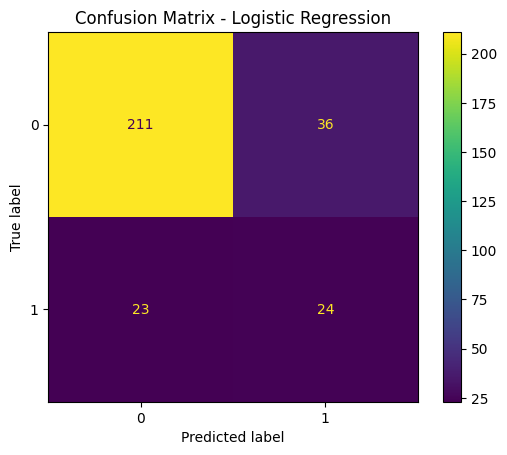

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_estimator(
    lr,
    X_test,
    y_test
)

plt.title("Confusion Matrix - Logistic Regression")
plt.show()

## 21. ROC Curve - Logistic Regression

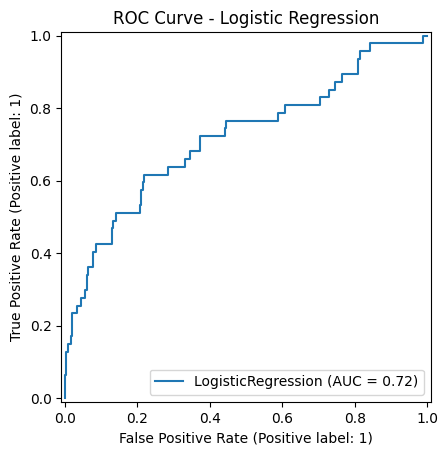

In [ ]:
from sklearn.metrics import RocCurveDisplay
import matplotlib.pyplot as plt

RocCurveDisplay.from_estimator(
    lr,
    X_test,
    y_test
)

plt.title("ROC Curve - Logistic Regression")
plt.show()

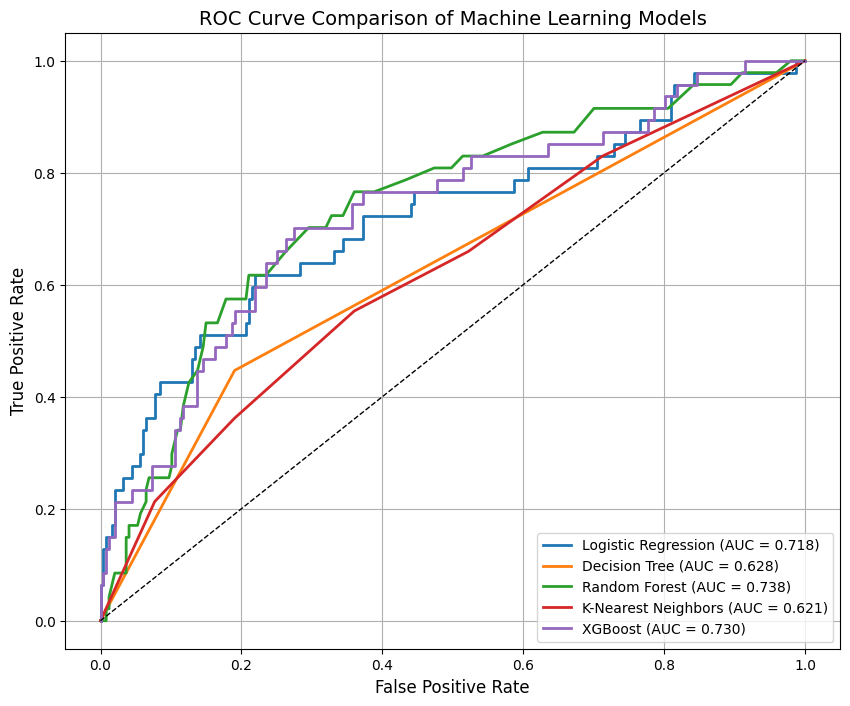


ROC-AUC Scores

Logistic Regression      : 0.7182
Decision Tree            : 0.6283
Random Forest            : 0.7378
K-Nearest Neighbors      : 0.6214
XGBoost                  : 0.7299


In [ ]:
# ==============================
# ROC-AUC Analysis for All Models
# ==============================

import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score

# Store all trained models
models = {
    "Logistic Regression": lr,
    "Decision Tree": dt,
    "Random Forest": rf,
    "K-Nearest Neighbors": knn,
    "XGBoost": xgb
}

plt.figure(figsize=(10,8))

auc_scores = {}

for name, model in models.items():

    # Probability prediction
    y_prob = model.predict_proba(X_test)[:,1]

    # ROC Curve
    fpr, tpr, thresholds = roc_curve(y_test, y_prob)

    # AUC Score
    auc = roc_auc_score(y_test, y_prob)
    auc_scores[name] = auc

    plt.plot(fpr,
             tpr,
             linewidth=2,
             label=f"{name} (AUC = {auc:.3f})")

# Random Classifier
plt.plot([0,1],[0,1],'k--',linewidth=1)

plt.xlabel("False Positive Rate", fontsize=12)
plt.ylabel("True Positive Rate", fontsize=12)
plt.title("ROC Curve Comparison of Machine Learning Models", fontsize=14)
plt.legend(loc="lower right")
plt.grid(True)

plt.show()

# Print AUC Scores
print("\nROC-AUC Scores\n")
for model, score in auc_scores.items():
    print(f"{model:25s}: {score:.4f}")

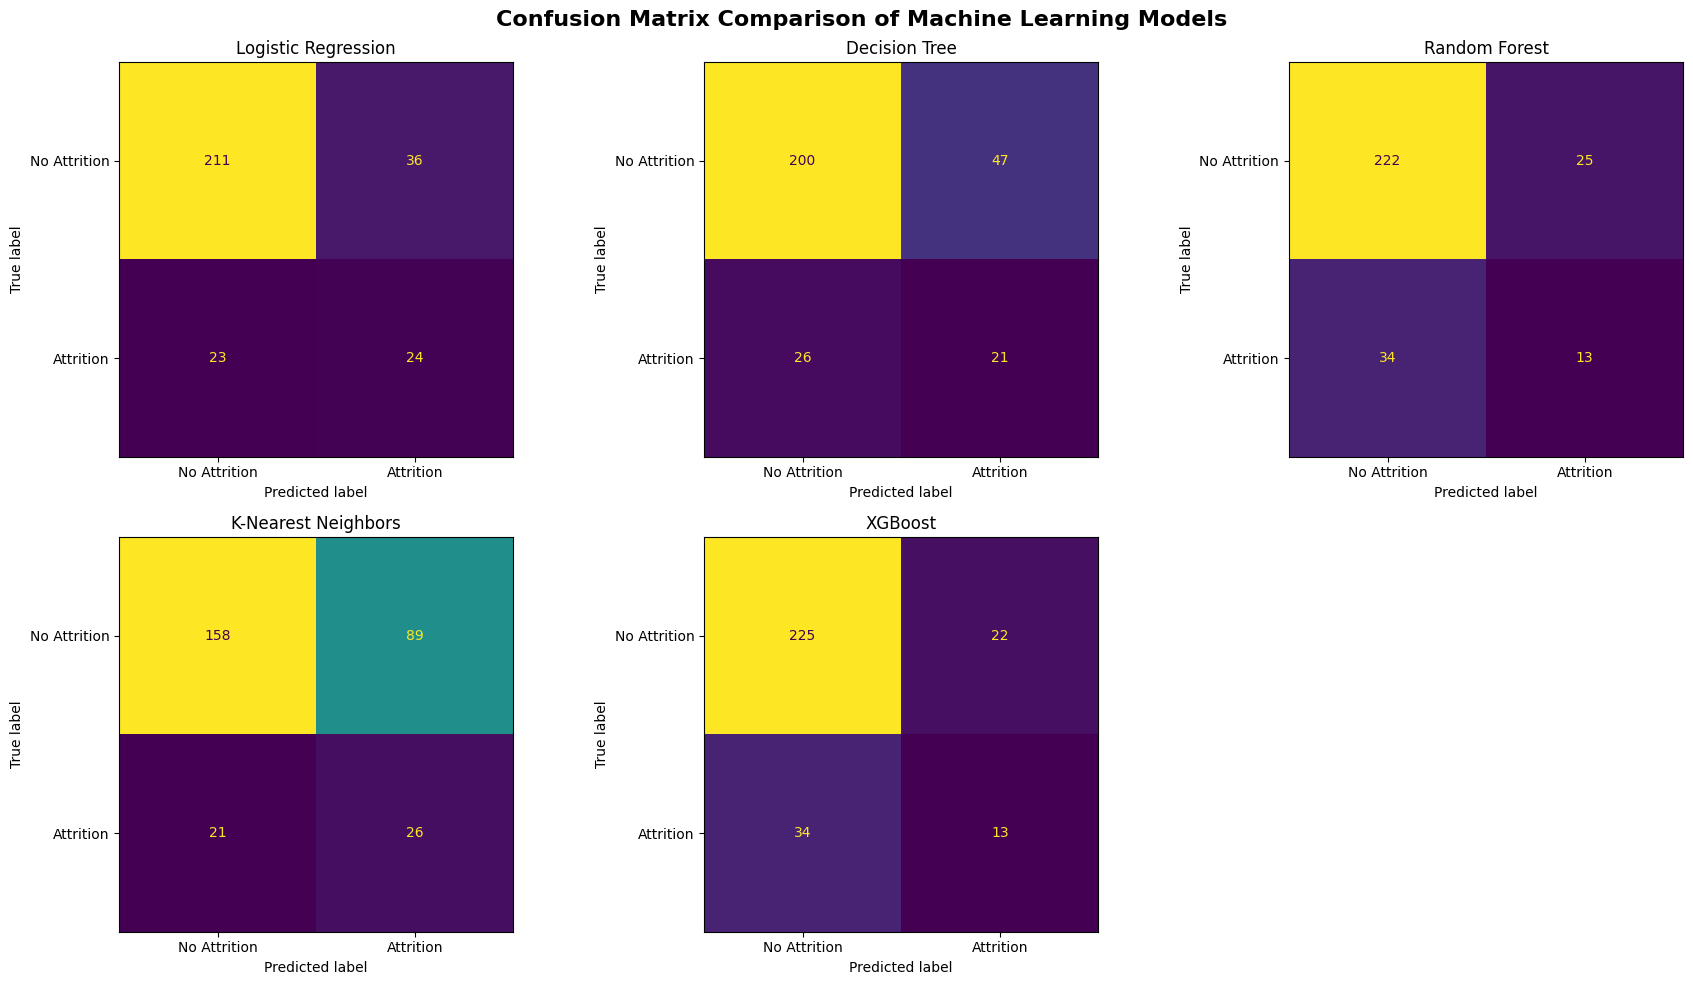

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

# Dictionary of trained models
models = {
    "Logistic Regression": lr,
    "Decision Tree": dt,
    "Random Forest": rf,
    "K-Nearest Neighbors": knn,
    "XGBoost": xgb
}

# Create subplot layout
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for ax, (name, model) in zip(axes, models.items()):

    # Prediction
    y_pred = model.predict(X_test)

    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)

    # Display
    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=["No Attrition", "Attrition"]
    )

    disp.plot(ax=ax, colorbar=False)
    ax.set_title(name, fontsize=12)

# Remove empty subplot
fig.delaxes(axes[-1])

plt.suptitle("Confusion Matrix Comparison of Machine Learning Models",
             fontsize=16,
             fontweight='bold')

plt.tight_layout()
plt.show()

In [ ]:
from sklearn.metrics import confusion_matrix

for name, model in models.items():

    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)

    print("="*50)
    print(name)
    print(cm)

Logistic Regression
[[211  36]
 [ 23  24]]
Decision Tree
[[200  47]
 [ 26  21]]
Random Forest
[[222  25]
 [ 34  13]]
K-Nearest Neighbors
[[158  89]
 [ 21  26]]
XGBoost
[[225  22]
 [ 34  13]]


## 22. AUC Score - Logistic Regression

In [ ]:
from sklearn.metrics import roc_auc_score

y_prob = xgb.predict_proba(X_test)[:,1]

auc = roc_auc_score(y_test,y_prob)

print("ROC AUC:",auc)

ROC AUC: 0.7440778706176242


# Model Comparison

## 23. Compare Performance of All Models

In [ ]:
results = pd.DataFrame(
[
    lr_result,
    dt_result,
    rf_result,
    knn_result,
    xgb_result
],
columns=[
    "Model",
    "Accuracy",
    "Precision",
    "Recall",
    "F1 Score"
]
)

results
results

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.799320,0.400000,0.510638,0.448598
1,Decision Tree,0.751701,0.308824,0.446809,0.365217
2,Random Forest,0.799320,0.342105,0.276596,0.305882
3,K-Nearest Neighbors,0.625850,0.226087,0.553191,0.320988
4,XGBoost,0.809524,0.371429,0.276596,0.317073


# Model Comparison

## 24. Performance Comparison of Machine Learning Models

In [ ]:
results = results.sort_values(
    by="F1 Score",
    ascending=False
)

results

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.799320,0.400000,0.510638,0.448598
1,Decision Tree,0.751701,0.308824,0.446809,0.365217
3,K-Nearest Neighbors,0.625850,0.226087,0.553191,0.320988
4,XGBoost,0.809524,0.371429,0.276596,0.317073
2,Random Forest,0.799320,0.342105,0.276596,0.305882


## 25. F1 Score Comparison of Machine Learning Models

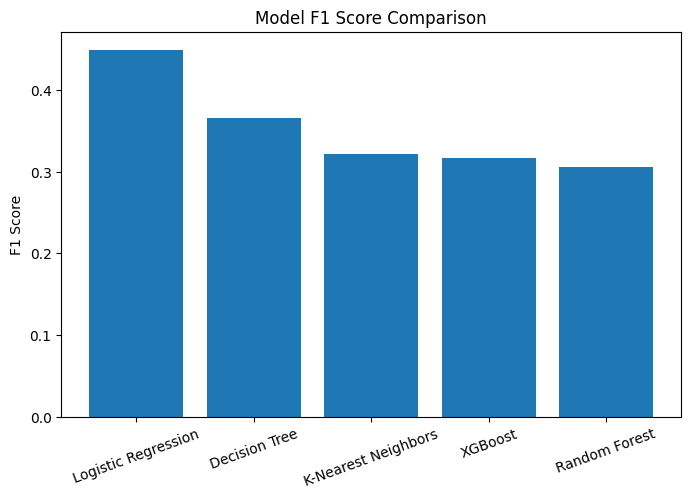

In [ ]:
plt.figure(figsize=(8,5))

plt.bar(results["Model"], results["F1 Score"])

plt.xticks(rotation=20)

plt.ylabel("F1 Score")

plt.title("Model F1 Score Comparison")

plt.show()

## Retention Recommendation System

In [ ]:
def recommend_retention_actions(model, X_data, original_df, threshold=0.5):
    """
    Recommends retention actions for employees at high risk of attrition.

    Args:
        model: The trained classification model (e.g., best_rf).
        X_data: The preprocessed feature data (X_test or X_train).
        original_df: The original or preprocessed DataFrame containing employee details.
        threshold (float): The probability threshold for classifying high attrition risk.

    Returns:
        pandas.DataFrame: A DataFrame with employee details and recommended actions.
    """
    attrition_probabilities = model.predict_proba(X_data)[:, 1]

    high_risk_indices = np.where(attrition_probabilities >= threshold)[0]

    high_risk_employees = original_df.iloc[high_risk_indices].copy()

    if not high_risk_employees.empty:
        high_risk_employees['Attrition_Probability'] = attrition_probabilities[high_risk_indices]
        high_risk_employees['Recommended_Action'] = (
            'Review compensation and career path' if high_risk_employees['JobLevel'] < 2 else
            'Offer mentorship and development programs' if high_risk_employees['TotalWorkingYears'] < 5 else
            'Conduct stay interview and address concerns'
        )
    else:
        print("No employees identified as high-risk based on the given threshold.")

    return high_risk_employees


In [ ]:
df = pd.read_csv('employee_attrition_preprocessed.csv')

X_full = df.drop('Attrition', axis=1)

full_attrition_probabilities = best_rf.predict_proba(scaler.transform(X_full))[:, 1]

df['Attrition_Probability'] = full_attrition_probabilities

high_risk_employees_df = df[df['Attrition_Probability'] >= 0.5].copy()

high_risk_employees_df['Recommended_Action'] = None
high_risk_employees_df.loc[high_risk_employees_df['JobLevel'] < 2, 'Recommended_Action'] = 'Review compensation and career path'
high_risk_employees_df.loc[high_risk_employees_df['TotalWorkingYears'] < 5, 'Recommended_Action'] = 'Offer mentorship and development programs'
high_risk_employees_df.loc[
    (high_risk_employees_df['JobLevel'] >= 2) &
    (high_risk_employees_df['TotalWorkingYears'] >= 5),
    'Recommended_Action'
] = 'Conduct stay interview and address concerns'

print(f"Found {len(high_risk_employees_df)} high-risk employees:")
display(high_risk_employees_df[['Age', 'Department', 'JobRole', 'Attrition_Probability', 'Recommended_Action']].head())

Found 229 high-risk employees:


,Age,Department,JobRole,Attrition_Probability,Recommended_Action
0,41,2,7,0.86,Conduct stay interview and address concerns
3,33,1,6,0.55,Review compensation and career path
14,28,1,2,0.88,Review compensation and career path
21,36,2,8,0.86,Review compensation and career path
26,32,1,6,0.91,Review compensation and career path
